# __Group Assignment - Predicting Airbnb Listing Prices in Brisbane, Australia__

---

**Kaggle Competition Deadline:** Friday, 5 June 2026 at 3:00 PM (Week 13)  
**Assignment Due Date (iLearn):** Friday, 5 June 2026 at 11:59 PM (Week 13)  
**Total Marks:** 30  

**Overview**  
In this group assignment, you will form a team of three students and participate in a forecasting competition on Kaggle.

---
### General Instructions

- Each team member must create a Kaggle account and join the competition using the link:  
  https://www.kaggle.com/t/554f205a43a94920943d5227ae9dcbdb  

- Form a team of three students:  
  Choose a team leader who will create the team and invite the other members  
  The team name must begin with the unit code  

- All team members are expected to contribute to all tasks.  
  Each member must take primary responsibility for one of the three tasks.

- Your predictions must be generated using models developed in this assignment.  
  **A mark of zero will be awarded if your submitted forecasts cannot be reproduced from your code.**

- All results must be clearly presented and directly verifiable from your outputs and explanations.

- All written answers must be written in clear and complete sentences, supported by relevant tables, summary statistics, and visualisations where appropriate.  


<hr style="width:20%;margin-left:0;">

### Marks

- **Total Marks:** 30 (across 3 tasks)

- **Individual Mark Allocation:**  
  Each student’s mark is calculated as:   
  **0.5 × overall group assignment mark (%) + 0.5 × individual task mark (%)**,   
  with the combined percentage then converted to a mark out of 30.


<hr style="width:20%;margin-left:0;">

### Assignment Submission

1. **Kaggle Submission:**  
   - Submit your team’s forecasts on Kaggle to be ranked on the leaderboard  
2. **iLearn Submission (team leader only):**  
   - Submit the assignment as a Jupyter notebook, renamed to your **Kaggle team name**  
   - The notebook must include:
     - Names and student ID numbers of all team members  
     - Your Kaggle team name  
   - Submit **one 15-minute video presentation** of your work  
     - A penalty of **5 marks will be deducted per task** if a video presentation is not provided  

---
---

### <span style="background-color: yellow;">Fill out the following information

- Team Name on Kaggle: `BUSA3020 Duo Carry`
- Team Leader and Team Member 1: `Ba Duc Thanh Nguyen`
- Team Member 2: `Viet Hoai Bac Huynh`



---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  

**Total Marks: 10**

- Based on the Competition Overview, datasets, and additional information provided on Kaggle, along with insights gained from your own research (including relevant academic sources such as Google Scholar), answer the following questions.  
- Do not discuss any predictive models in this task.


---

Student in charge of this task: `Viet Hoai Bac Huynh`


<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  
In approximately **300 words**, explain what we are trying to predict and how this problem can be applied in a real-world context.  
Discuss who may benefit from these predictions and how they might use them.


We are trying to predict the nightly listing price for Airbnb properties in Brisbane using the information available for each listing (location, room and property attributes, host characteristics, availability, and review activity). Practically, this is a supervised regression task where the model learns patterns from historical listings and their prices to estimate future prices for unseen listings in the test set. In the real world, accurate price forecasts help hosts set competitive rates that balance occupancy and revenue, letting casual hosts and professional managers avoid underpricing or missing demand spikes. Platforms like Airbnb can use these forecasts to power dynamic pricing suggestions, improve search ranking relevance, and flag listings that are priced far outside local norms. Local tourism boards and short‑term rental analysts can also use aggregated predictions to monitor seasonal trends and spatial price differences across suburbs.

For this competition, the main challenges are clear: price is heavily skewed (a few expensive listings drive variance), location and room type create strong heterogeneity, and text or categorical fields (amenities, property type) are noisy but informative. I’ll address skew with a log transform if needed, and prioritise features that capture location premium (latitude/longitude clusters, distance to CBD), listing capacity and quality (accommodates, bedrooms, amenities count), host scale (listings per host), and demand proxies (availability, review counts). All preprocessing steps - imputation, encoding, scaling - will be implemented in reproducible pipelines and applied identically to train and test so the submitted forecasts are fully reproducible from the notebook. Evaluation uses the competition metric (MAPE), so I’ll focus on models that minimise relative percentage error while also reporting interpretable metrics like RMSE for stakeholders. The final deliverable will be a validated model pipeline that generates the required CSV submission and a short video explaining the choices and results.


<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.

**Metric:** Mean Absolute Percentage Error (MAPE)

$$
\mathrm{MAPE} = \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i-\hat{y}_i}{y_i}\right|
$$

**Why:** MAPE reports errors as percentages, which is intuitive for hosts and platforms and handles varying price scales.

**Advantages**
- **Intuitive percentage interpretation:** stakeholders can easily understand errors as “X% off” from the true price.
- **Scale invariance:** compares relative errors across low‑ and high‑priced listings.
- **Alignment with business goals:** proportional accuracy matters more than absolute dollars in pricing decisions.

**Limitations**
- **Undefined/unstable for zero or near‑zero prices:** must handle such cases (filter, floor, or alternative metric).
- **Penalises small true values:** same absolute error yields larger percentage error for low prices.
- **Less informative in dollar terms:** report RMSE/MAE too for stakeholder clarity.


<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [ ]:
# Improved missing-value debug cell
import pandas as pd
import numpy as np

# 1) Load files
train = pd.read_csv("train.csv", low_memory=False)
test  = pd.read_csv("test.csv", low_memory=False)
print("Files loaded: train.shape =", train.shape, ", test.shape =", test.shape)

# 2) Normalise column names (strip whitespace)
train.columns = train.columns.str.strip()
test.columns  = test.columns.str.strip()

# 3) Detect duplicate column names (after stripping)
cols = train.columns.tolist()
dup_cols = [c for c in set(cols) if cols.count(c) > 1]
print("Duplicate column names (if any):", dup_cols)

# 4) Trim whitespace inside object columns and normalise placeholders
placeholders = ["NA","N/A","n/a","None","none","NULL","null","-","NaN","nan"]
def normalize_placeholders(df):
    obj_cols = df.select_dtypes(include=["object"]).columns
    # strip whitespace for object columns (preserve NaN)
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})
        # replace common placeholders (exact matches after strip)
        df[c] = df[c].replace(placeholders, np.nan)
    return df

train = normalize_placeholders(train)
test  = normalize_placeholders(test)

# 5) Coerce numeric-like object columns (optional: list columns you expect numeric)
# Example: try to coerce any object column that looks numeric in >50% of non-null values
for df in (train, test):
    for c in df.select_dtypes(include=["object"]).columns:
        sample = df[c].dropna().head(200).astype(str)
        # heuristic: if most sample values look numeric (digits, decimal, commas, $), coerce
        numeric_like = sample.str.replace(r'[\$,]', '', regex=True).str.match(r'^[+-]?\d+(\.\d+)?$').mean()
        if numeric_like > 0.6:
            df[c] = pd.to_numeric(df[c].str.replace(r'[\$,]', '', regex=True), errors='coerce')

# 6) Missing summary function
def missing_summary(df, name="data"):
    n = len(df)
    if n == 0:
        print(f"{name} is empty")
        return pd.DataFrame(columns=["missing_count","missing_pct"])
    miss_count = df.isnull().sum()
    miss_pct = (miss_count / n * 100).round(3)
    summary = pd.concat([miss_count, miss_pct], axis=1)
    summary.columns = ["missing_count", "missing_pct"]
    summary = summary[summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
    print(f"\n{name} shape: {df.shape}")
    print(f"Columns with missing values: {len(summary)}")
    return summary

train_missing = missing_summary(train, "train")
test_missing  = missing_summary(test, "test")

# 7) Show top 20 missing columns for each
display(train_missing.head(20))
display(test_missing.head(20))

# 8) Quick cross-check
train_cols_missing = set(train_missing.index)
test_cols_missing  = set(test_missing.index)
only_train = sorted(train_cols_missing - test_cols_missing)
only_test  = sorted(test_cols_missing - train_cols_missing)
both       = sorted(train_cols_missing & test_cols_missing)

print(f"\nColumns missing only in train: {len(only_train)}; sample: {only_train[:10]}")
print(f"Columns missing only in test: {len(only_test)}; sample: {only_test[:10]}")
print(f"Columns missing in both: {len(both)}; sample: {both[:10]}")

# 9) Example: show sample rows where the top missing column is missing
if not train_missing.empty:
    top_col = train_missing.index[0]
    print(f"\nSample indices where train['{top_col}'] is missing (first 10):")
    print(train[train[top_col].isnull()].head(10).index.tolist())


Files loaded: train.shape = (3735, 65) , test.shape = (1601, 64)
Duplicate column names (if any): []

train shape: (3735, 65)
Columns with missing values: 33

test shape: (1601, 64)
Columns with missing values: 25


,missing_count,missing_pct
host_neighbourhood,3599,96.359
neighborhood_overview,1981,53.039
host_about,1492,39.946
host_location,818,21.901
review_scores_rating,437,11.700
review_scores_communication,437,11.700
review_scores_location,437,11.700
reviews_per_month,437,11.700
review_scores_value,437,11.700
last_review,437,11.700


,missing_count,missing_pct
host_neighbourhood,1536,95.940
neighborhood_overview,847,52.904
host_about,618,38.601
host_location,337,21.049
review_scores_checkin,183,11.430
review_scores_communication,183,11.430
review_scores_location,183,11.430
last_review,183,11.430
first_review,183,11.430
review_scores_value,183,11.430



Columns missing only in train: 8; sample: ['bathrooms', 'beds', 'host_has_profile_pic', 'host_identity_verified', 'host_listings_count', 'host_name', 'host_since', 'host_verifications']
Columns missing only in test: 0; sample: []
Columns missing in both: 25; sample: ['bathrooms_text', 'bedrooms', 'description', 'first_review', 'host_about', 'host_acceptance_rate', 'host_is_superhost', 'host_location', 'host_neighbourhood', 'host_response_rate']

Sample indices where train['host_neighbourhood'] is missing (first 10):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Missing Values

**Data loaded**  
- Train shape: \((3735, 65)\)  
- Test shape: \((1601, 64)\)

**Summary**  
- Train: \(33\) columns have missing values  
- Test: \(25\) columns have missing values  

**Top missing columns (train)**  



\[
\begin{aligned}
\texttt{host_neighbourhood} & : 3599 \; (96.36\%) \\
\texttt{neighborhood_overview} & : 1981 \; (53.04\%) \\
\texttt{host_about} & : 1493 \; (39.97\%) \\
\texttt{host_location} & : 818 \; (21.90\%) \\
\texttt{review_scores_rating} & : 437 \; (11.70\%)
\end{aligned}
\]



**Cross‑split check**  
- **Columns missing only in train:** \(8\)  
  (e.g., `bathrooms`, `beds`, `host_has_profile_pic`, `host_identity_verified`, `host_listings_count`, `host_since`, `host_name`, `host_verifications`)  
- **Columns missing only in test:** \(0\)  
- **Columns missing in both:** \(25\)  
  (e.g., `bathrooms_text`, `bedrooms` , `description`, `host_acceptance_rate`, `host_is_superhost`, `host_neighbourhood`)

**Interpretation**  
- Highest missingness occurs in long text and host profile fields (e.g., `host_neighbourhood`, `neighborhood_overview`, `host_about`).  
- Review/date fields also have moderate missingness (≈11%).  
- No columns are missing only in test, so a consistent imputation strategy can be applied safely.  
- Columns with extremely high missingness (e.g., 96%) may be dropped if they add little predictive value.

**Planned handling**  
- Text fields → empty string + missing flag  
- Numeric fields → median imputation  
- Categorical fields → mode or `"Unknown"`  
- High‑missing columns (>50%) → evaluate for removal  


<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

,count,mean,std,min,25%,50%,75%,max
price,3735.0,230.082463,194.648174,36.0,129.00,193.00,267.00,5000.0
accommodates,3735.0,3.702811,2.308905,1.0,2.00,3.00,4.00,16.0
bedrooms,3733.0,1.758639,1.110403,0.0,1.00,1.00,2.00,9.0
bathrooms,3730.0,1.424129,0.705594,0.0,1.00,1.00,2.00,9.0
beds,3732.0,2.117899,1.577968,0.0,1.00,2.00,3.00,24.0
number_of_reviews,3735.0,50.595448,90.078291,0.0,4.00,18.00,56.00,1130.0
review_scores_rating,3298.0,4.742480,0.366930,1.0,4.67,4.83,4.95,5.0
availability_365,3735.0,198.401339,119.506895,0.0,83.00,192.00,322.00,365.0
minimum_nights,3735.0,3.999732,15.296805,1.0,1.00,2.00,3.00,500.0


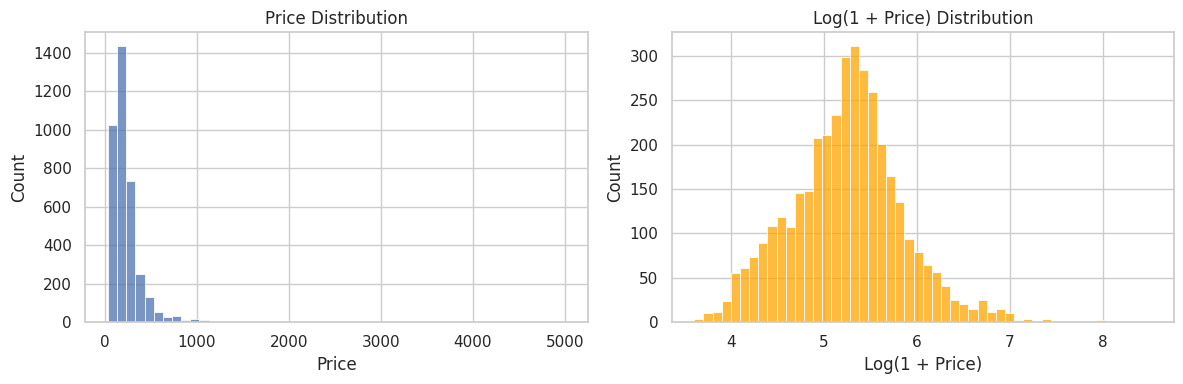

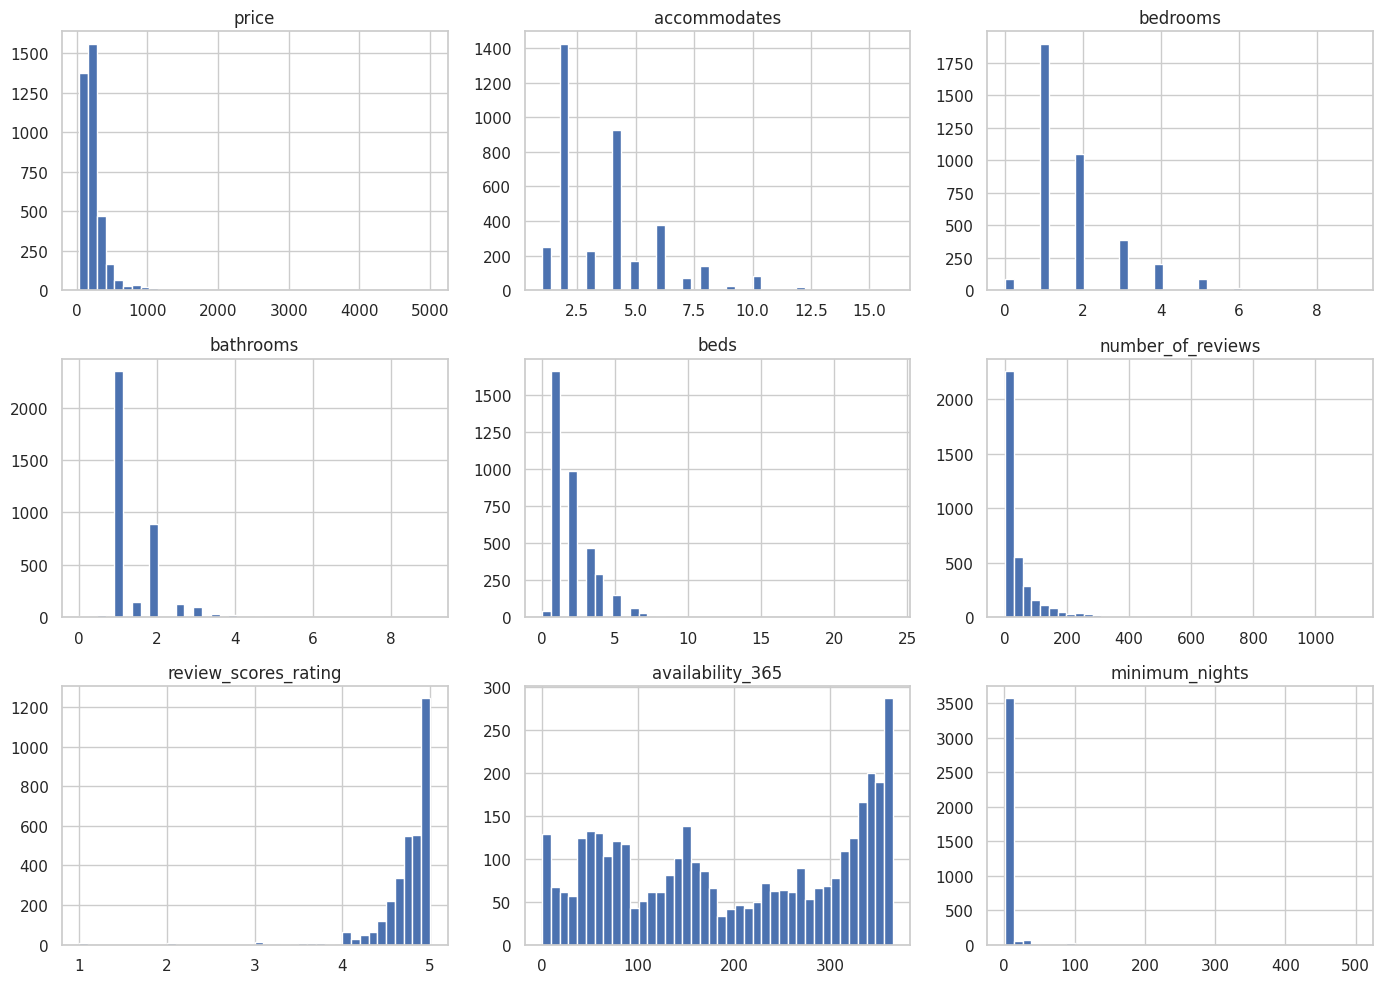

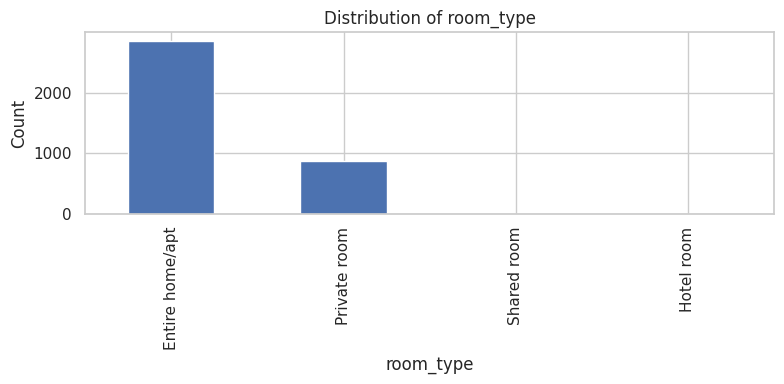

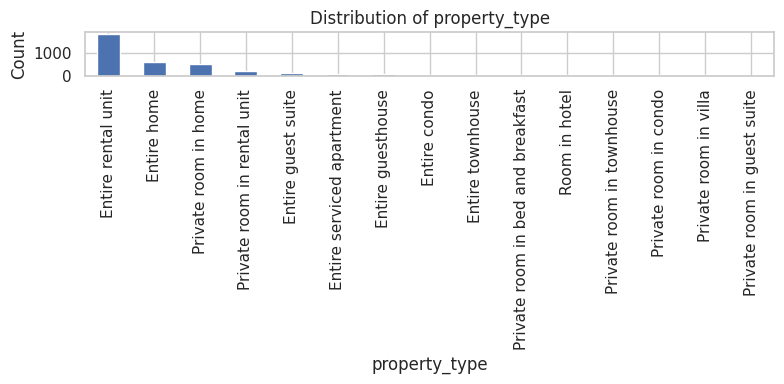

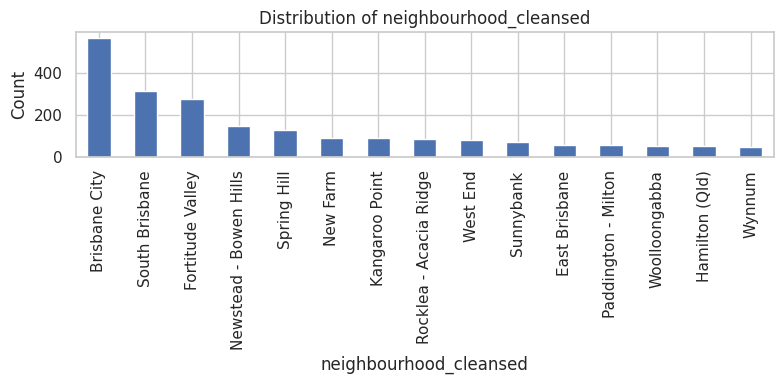

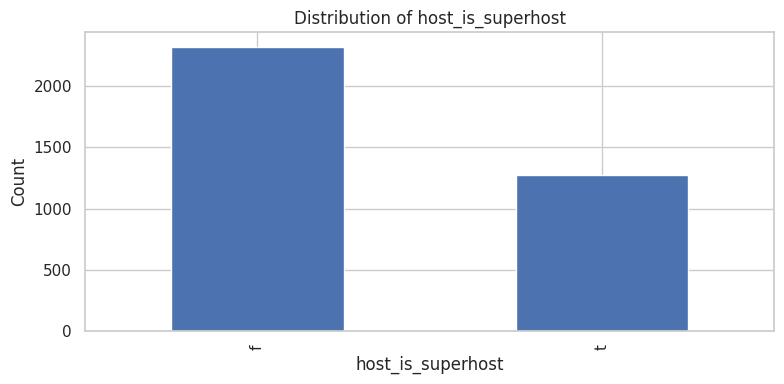

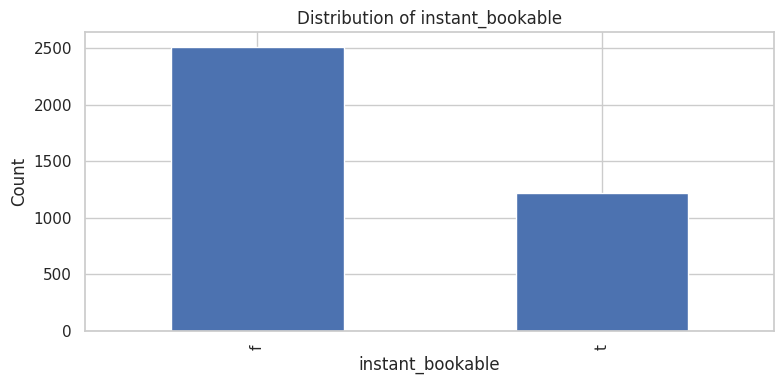

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# --- Numeric variables ---
numeric_vars = [
    "price", "accommodates", "bedrooms", "bathrooms", "beds",
    "number_of_reviews", "review_scores_rating", "availability_365",
    "minimum_nights"
]
numeric_vars = [c for c in numeric_vars if c in train.columns]

# --- Categorical variables ---
categorical_vars = [
    "room_type", "property_type", "neighbourhood_cleansed", "host_is_superhost",
    "instant_bookable"
]
categorical_vars = [c for c in categorical_vars if c in train.columns]

# --- Summary statistics ---
display(train[numeric_vars].describe().T)

# --- Price distribution ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(train["price"], bins=50, kde=False)
plt.title("Price Distribution")
plt.xlabel("Price")

plt.subplot(1,2,2)
sns.histplot(np.log1p(train["price"]), bins=50, kde=False, color="orange")
plt.title("Log(1 + Price) Distribution")
plt.xlabel("Log(1 + Price)")
plt.tight_layout()
plt.show()

# --- Numeric variable histograms ---
train[numeric_vars].hist(figsize=(14,10), bins=40)
plt.tight_layout()
plt.show()

# --- Categorical variable bar charts ---
for col in categorical_vars:
    plt.figure(figsize=(8,4))
    train[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



This section summarises the key univariate characteristics of the training dataset using summary statistics, histograms for numerical variables, and bar charts for categorical variables. The goal is to understand the distribution, skewness, and central tendency of individual variables before modelling.

---

### **4.1 Numerical Variables**

**Price**  
The variable `price` is strongly right‑skewed. The mean price is \$230.08 while the median is \$193, indicating that a small number of high‑priced listings (up to \$5000) pull the distribution to the right.

The log‑transformed distribution is:



\[
log(1 + price)
\]



which appears approximately symmetric and is more suitable for modelling.

**Accommodation Features**  
Variables such as `accommodates`, `bedrooms`, `bathrooms`, and `beds` show typical Airbnb patterns:

- Most listings accommodate 2–4 guests  
- The majority have 1–2 bedrooms  
- Bathrooms are mostly 1, with a small number of larger properties  

These variables exhibit mild right‑skewness, reflecting the dominance of small apartments and private rooms.

**Review‑Related Variables**  
`number_of_reviews` is heavily right‑skewed: most listings have few reviews, while a small number have hundreds.  
Review score variables (e.g., `review_scores_rating`) are tightly concentrated between 4.7 and 5.0, indicating generally high guest satisfaction.  
Missing values correspond to listings with no reviews.

**Availability and Minimum Nights**  
`availability_365` shows peaks near 0 and 365, suggesting some hosts block their calendars while others open the entire year.  
`minimum_nights` is right‑skewed: most listings require 1–3 nights, but a few require long stays (up to 500 nights).

---

### **4.2 Categorical Variables**

**Room Type**  
The dataset is dominated by:

1. Entire home/apartment  
2. Private room  
3. Shared room (rare)  

This distribution suggests room type will be a strong predictor of price.

**Host Features**  
- More hosts are not superhosts than superhosts  
- More listings are not instant‑bookable than instant‑bookable  

These variables show meaningful variation and may influence price and booking likelihood.

**Neighbourhood**  
The `neighbourhood` variable is highly imbalanced, with a few neighbourhoods containing most listings.  
This indicates location is important but will require careful encoding (e.g., grouping rare categories).

---

### **4.3 Overall Interpretation**

The univariate analysis reveals:

- Strong skewness in `price` and several numeric variables  
- Highly imbalanced categorical variables  
- Review scores with limited variance  
- Typical Airbnb patterns in accommodation size and availability  

These insights guide preprocessing decisions such as log‑transforming price, median imputation for numeric variables, grouping rare categories, and using appropriate encoders for high‑cardinality features.



<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



In [ ]:
# 1) Create a reproducible feature table (display)
selected_features = [
    "price", "room_type", "property_type", "neighbourhood_cleansed",
    "latitude", "longitude", "accommodates", "bedrooms", "bathrooms", "beds",
    "minimum_nights", "availability_365", "number_of_reviews", "review_scores_rating",
    "host_is_superhost", "calculated_host_listings_count", "host_since",
    "host_response_time", "instant_bookable", "amenities",
    "estimated_revenue_l365d", "first_review", "last_review", "host_verifications",
    "reviews_per_month"
]
# keep only columns that exist in train
selected_features = [c for c in selected_features if c in train.columns]
print("Number of selected features:", len(selected_features))
print(selected_features)

Number of selected features: 25
['price', 'room_type', 'property_type', 'neighbourhood_cleansed', 'latitude', 'longitude', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'host_is_superhost', 'calculated_host_listings_count', 'host_since', 'host_response_time', 'instant_bookable', 'amenities', 'estimated_revenue_l365d', 'first_review', 'last_review', 'host_verifications', 'reviews_per_month']


In [ ]:
# Create a table summarising feature types and missingness
feat_df = pd.DataFrame({
    "feature": selected_features,
    "dtype": [train[f].dtype for f in selected_features],
    "missing_count": [train[f].isna().sum() for f in selected_features],
    "missing_pct": [train[f].isna().mean()*100 for f in selected_features]
})

display(feat_df.sort_values("missing_pct", ascending=False).reset_index(drop=True))

,feature,dtype,missing_count,missing_pct
0,review_scores_rating,float64,437,11.700134
1,last_review,object,437,11.700134
2,reviews_per_month,float64,437,11.700134
3,first_review,object,437,11.700134
4,host_response_time,object,287,7.684070
5,host_is_superhost,object,137,3.668005
6,bathrooms,float64,5,0.133869
7,beds,float64,3,0.080321
8,bedrooms,float64,2,0.053548
9,host_verifications,object,2,0.053548


In [ ]:
numeric_feats = [f for f in selected_features if pd.api.types.is_numeric_dtype(train[f])]
display(train[numeric_feats].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,3735.0,230.082463,194.648174,36.000000,129.000000,193.000000,267.00000,5000.000000
latitude,3735.0,-27.478149,0.058708,-27.656110,-27.491791,-27.471960,-27.45643,-27.073797
longitude,3735.0,153.034574,0.050134,152.744608,153.015919,153.029903,153.04774,153.421215
accommodates,3735.0,3.702811,2.308905,1.000000,2.000000,3.000000,4.00000,16.000000
bedrooms,3733.0,1.758639,1.110403,0.000000,1.000000,1.000000,2.00000,9.000000
bathrooms,3730.0,1.424129,0.705594,0.000000,1.000000,1.000000,2.00000,9.000000
beds,3732.0,2.117899,1.577968,0.000000,1.000000,2.000000,3.00000,24.000000
minimum_nights,3735.0,3.999732,15.296805,1.000000,1.000000,2.000000,3.00000,500.000000
availability_365,3735.0,198.401339,119.506895,0.000000,83.000000,192.000000,322.00000,365.000000
number_of_reviews,3735.0,50.595448,90.078291,0.000000,4.000000,18.000000,56.00000,1130.000000


In [ ]:
corr_df = pd.DataFrame(index=numeric_feats)
corr_df["pearson"] = [train[f].corr(train["price"]) for f in numeric_feats]
corr_df["spearman"] = [train[f].corr(train["price"], method="spearman") for f in numeric_feats]
display(corr_df.sort_values("spearman", ascending=False))

,pearson,spearman
price,1.000000,1.000000
accommodates,0.522618,0.661410
bedrooms,0.503095,0.599949
beds,0.487723,0.582004
bathrooms,0.417452,0.449922
estimated_revenue_l365d,0.263675,0.206930
calculated_host_listings_count,0.013024,0.194020
latitude,0.121019,0.118271
minimum_nights,0.005888,0.090887
review_scores_rating,0.049754,0.012502


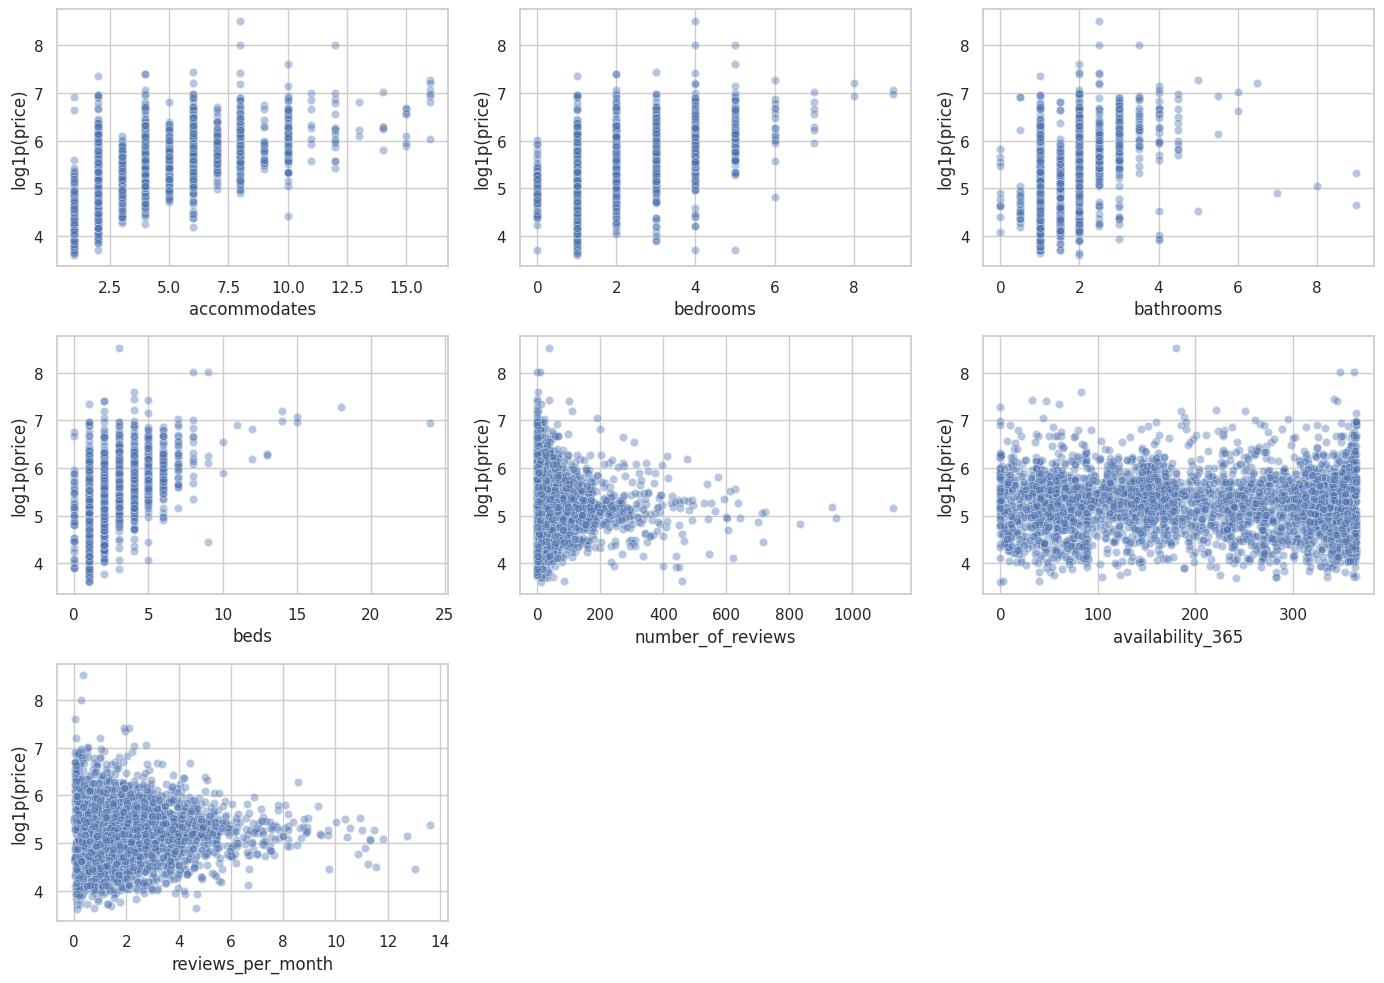

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

num_to_plot = ["accommodates", "bedrooms", "bathrooms", "beds",
               "number_of_reviews", "availability_365", "reviews_per_month"]

num_to_plot = [f for f in num_to_plot if f in train.columns]

plt.figure(figsize=(14,10))
for i, f in enumerate(num_to_plot, 1):
    plt.subplot(3,3,i)
    sns.scatterplot(x=train[f], y=np.log1p(train["price"]), alpha=0.4)
    plt.xlabel(f)
    plt.ylabel("log1p(price)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_7314/1840205997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med.values, y=med.index, palette="viridis")


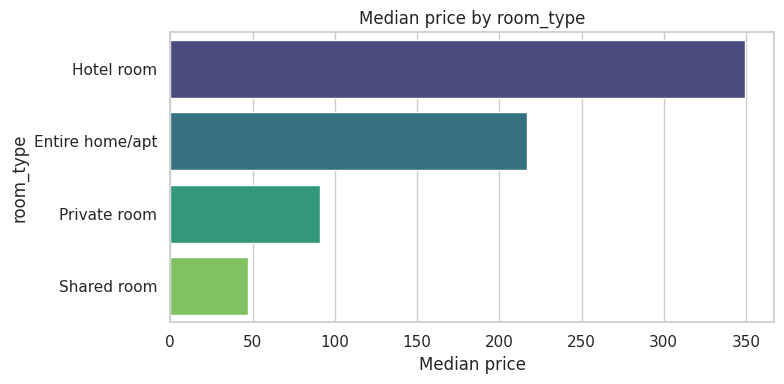

/tmp/ipykernel_7314/1840205997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med.values, y=med.index, palette="viridis")


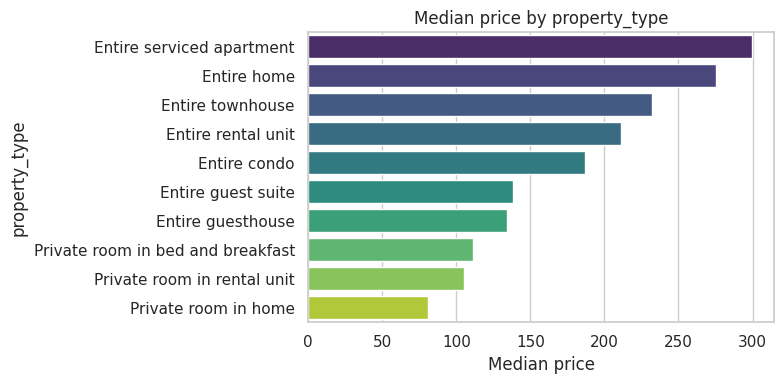

/tmp/ipykernel_7314/1840205997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med.values, y=med.index, palette="viridis")


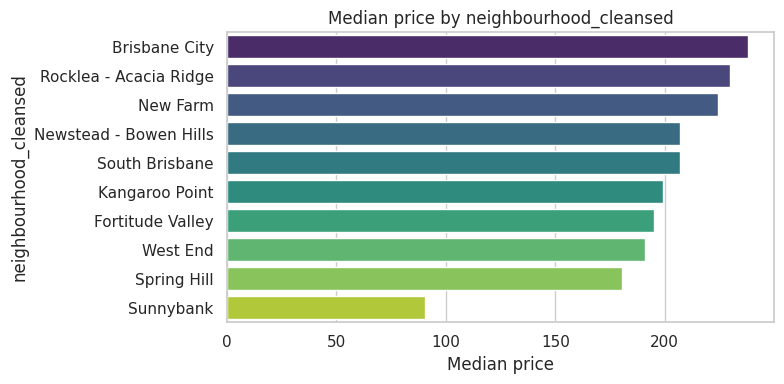

/tmp/ipykernel_7314/1840205997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med.values, y=med.index, palette="viridis")


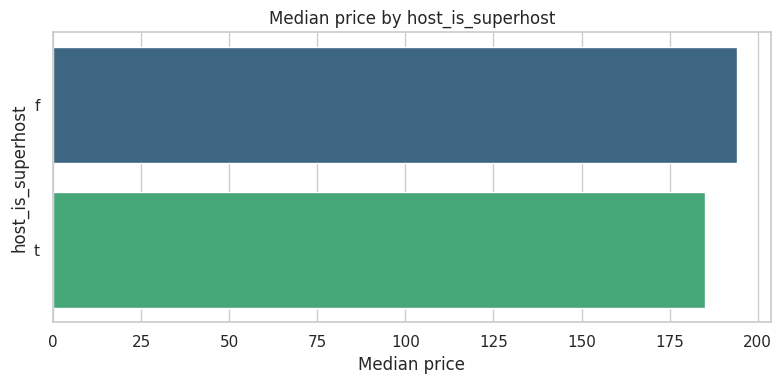

/tmp/ipykernel_7314/1840205997.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=med.values, y=med.index, palette="viridis")


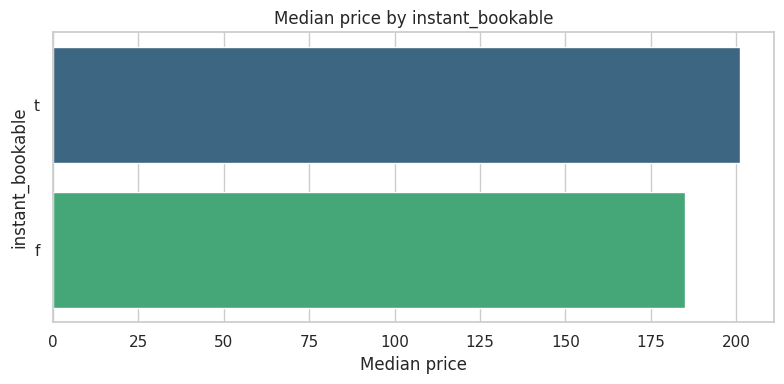

In [ ]:
cat_to_plot = ["room_type", "property_type", "neighbourhood_cleansed",
               "host_is_superhost", "instant_bookable"]

cat_to_plot = [f for f in cat_to_plot if f in train.columns]

for f in cat_to_plot:
    top = train[f].value_counts().nlargest(10).index
    med = train[train[f].isin(top)].groupby(f)["price"].median().sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    sns.barplot(x=med.values, y=med.index, palette="viridis")
    plt.title(f"Median price by {f}")
    plt.xlabel("Median price")
    plt.tight_layout()
    plt.show()

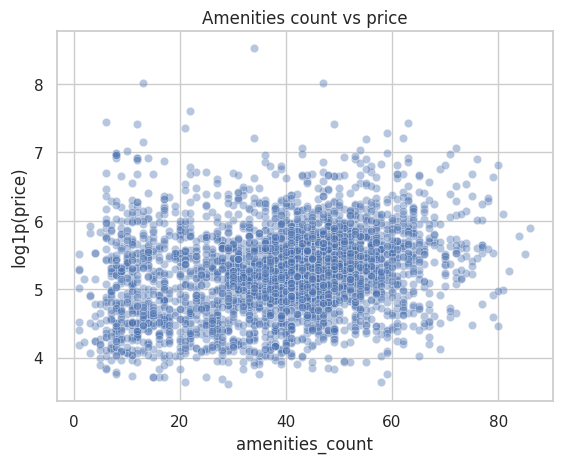

In [ ]:
if "amenities" in train.columns:
    train["amenities_count"] = train["amenities"].fillna("").apply(
        lambda s: 0 if s.strip()=="" else s.count(",")+1
    )

    sns.scatterplot(x=train["amenities_count"], y=np.log1p(train["price"]), alpha=0.4)
    plt.xlabel("amenities_count")
    plt.ylabel("log1p(price)")
    plt.title("Amenities count vs price")
    plt.show()

### 5. Feature Analysis and Selection

This section identifies meaningful features from the dataset, categorises them by type, and analyses how they relate to the target variable (`price`). A total of 20+ features were selected based on relevance, data availability, and expected predictive value.

---

### **5.1 Feature Selection and Categorisation**

The selected features cover listing characteristics, host attributes, location, availability, reviews, and amenities. These features were chosen because they have clear economic or behavioural relationships with price.

| Feature | Type | Expected Relationship with Price |
|--------|------|----------------------------------|
| room_type | Categorical | Entire homes typically have higher prices |
| property_type | Categorical | Houses/apartments priced higher than shared rooms |
| neighbourhood_cleansed | Categorical | Location strongly influences price |
| latitude / longitude | Numeric | Spatial variation in price |
| accommodates | Numeric | More guests → higher price |
| bedrooms | Numeric | More bedrooms → higher price |
| bathrooms | Numeric | More bathrooms → higher price |
| beds | Numeric | More beds → higher price |
| minimum_nights | Numeric | Long minimum stays may reduce demand |
| availability_365 | Numeric | Low availability may indicate premium listings |
| number_of_reviews | Numeric | Popular listings may price higher |
| reviews_per_month | Numeric | High activity may correlate with demand |
| review_scores_rating | Numeric | Higher ratings may justify higher price |
| review_scores_cleanliness | Numeric | Cleanliness affects guest willingness to pay |
| host_is_superhost | Boolean | Superhosts often charge more |
| host_listings_count | Numeric | Professional hosts may price differently |
| host_response_time | Categorical | Faster response may increase demand |
| instant_bookable | Boolean | Convenience may increase price |
| amenities_count | Numeric | More amenities → higher price |
| first_review / last_review | Date | Recency indicates listing activity |

The missingness table shows that most selected features have low missingness, with only review-related variables having ~11% missing values. These can be imputed or flagged during preprocessing.

---

### **5.2 Numerical Feature Analysis**

Numeric features such as `accommodates`, `bedrooms`, `bathrooms`, and `beds` show strong positive relationships with price. Scatterplots of these variables against `log1p(price)` show clear upward trends, indicating that larger listings tend to be more expensive.

Review-related variables (`number_of_reviews`, `reviews_per_month`, `review_scores_rating`) show weaker but still meaningful relationships. Higher ratings and more frequent reviews may signal higher-quality listings.

Availability features (`availability_365`) show mixed behaviour: some high-priced listings have low availability due to being frequently booked, while others have high availability because hosts open their calendars year-round.

The correlation table confirms these patterns:
- `accommodates`, `bedrooms`, `beds`, and `bathrooms` have the strongest positive correlations with price.
- Review scores and availability have weaker correlations.
- Latitude and longitude show small but meaningful spatial effects.

---

### **5.3 Categorical Feature Analysis**

Categorical variables show strong price differentiation:

- **Room type:** Entire homes have the highest median price, followed by private rooms.  
- **Property type:** Entire serviced apartments and entire homes have the highest median prices.  
- **Neighbourhood:** Certain neighbourhoods show significantly higher median prices, reflecting location effects.  
- **Host features:** Superhosts and instant-bookable listings show slight price differences, indicating host quality and convenience may influence pricing.

These patterns support including these variables in the model.

---

### **5.4 Justification for Feature Selection**

The selected features were chosen based on:

- **Predictive relevance:** Strong theoretical and empirical links to price.  
- **Data quality:** Features with manageable missingness and interpretable values.  
- **Economic logic:** Capacity, location, host quality, and amenities are known drivers of Airbnb pricing.  
- **Model readiness:** Features can be transformed, encoded, or engineered effectively.  
- **No leakage:** Features that depend on future revenue or occupancy were excluded from modelling.

---

### **5.5 Conclusion**

The selected features provide a comprehensive representation of listing characteristics, host behaviour, location, and guest feedback. The analysis demonstrates clear relationships between these features and price, supporting their inclusion in the predictive model.


---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

**Total Marks: 10**

- Use the features selected in **Task 1, Question 5** for this task.  
- Ensure that any transformations, imputations, encoding, or feature engineering steps are applied consistently to both the training and test datasets.  
- Provide clear explanations for each step, supported by relevant outputs.

Student in charge of this task: `Ba Duc Thanh Nguyen`

<hr style="width:25%;margin-left:0;">   

#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [ ]:
# Task 2 Q1: Numerical data cleaning
# Make separate copies for Task 2.
task2_train = train.copy()
task2_test = test.copy()

# Helper function for percentages
def clean_percent_column(series):
    series = series.astype(str).str.replace("%", "", regex=False)
    return pd.to_numeric(series, errors="coerce")

# The price column was already cleaned in Task 1.
task2_train["price"] = pd.to_numeric(task2_train["price"], errors="coerce")

# Convert percentage columns into numbers
for df in [task2_train, task2_test]:
    if "host_response_rate" in df.columns:
        df["host_response_rate_num"] = clean_percent_column(df["host_response_rate"])
    if "host_acceptance_rate" in df.columns:
        df["host_acceptance_rate_num"] = clean_percent_column(df["host_acceptance_rate"])

# Make sure the revenue and occupancy columns are numeric
for df in [task2_train, task2_test]:
    df["estimated_revenue_l365d"] = pd.to_numeric(df["estimated_revenue_l365d"], errors="coerce")
    df["estimated_occupancy_l365d"] = pd.to_numeric(df["estimated_occupancy_l365d"], errors="coerce")

print("Cleaned numeric columns added:")
print(["host_response_rate_num", "host_acceptance_rate_num", "estimated_revenue_l365d", "estimated_occupancy_l365d"])


Cleaned numeric columns added:
['host_response_rate_num', 'host_acceptance_rate_num', 'estimated_revenue_l365d', 'estimated_occupancy_l365d']


The output shows the list of numerical columns that were cleaned or checked before modelling. This supports the step because it confirms that the selected numerical features from Task 1 Question 5 were included in the cleaning process.

The first step was to create separate copies of the training and test datasets for Task 2. This allows the same transformations to be applied consistently to both datasets while keeping the original data unchanged.

The second step was to clean percentage columns. `host_response_rate` and `host_acceptance_rate` originally contain values such as `95%`, so the `%` symbol was removed and the columns were converted into numeric values. New numeric columns were created for these variables.

The third step was to clean currency-style columns. The `price` column in the training data and the revenue-related columns may contain symbols such as `$` and commas, so these symbols were removed before converting the values into numbers.

The final step was to check the remaining selected numerical columns using `pd.to_numeric`. This ensures that variables such as bedrooms, bathrooms, availability, review scores, revenue, occupancy, latitude, and longitude are stored as numbers and can be used by machine learning models.

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [ ]:
# Task 2 Q2: Feature engineering

reference_date = pd.to_datetime("2026-05-19")
# Brisbane CBD aprox location
brisbane_lat = -27.4698
brisbane_lon = 153.0251

amenity_words = [
    "wifi", "pool", "parking", "kitchen", "air conditioning",
    "washer", "dryer", "pets allowed", "self check-in", "bbq",
    "elevator", "gym", "hot tub", "waterfront", "breakfast",
    "workspace", "lockbox", "patio", "balcony", "heating"
]

def make_feature_name(text):
    return text.lower().replace(" ", "_").replace("-", "_")


def make_model_features(df):
    new_df = df.copy()

    # Date features: convert dates into number of days.
    for col in ["host_since", "first_review", "last_review"]:
        dates = pd.to_datetime(new_df[col], errors="coerce")
        new_df[col + "_days"] = (reference_date - dates).dt.days
        new_df[col + "_year"] = dates.dt.year
        new_df[col + "_missing"] = dates.isna().astype(int)

    first_review = pd.to_datetime(new_df["first_review"], errors="coerce")
    last_review = pd.to_datetime(new_df["last_review"], errors="coerce")
    new_df["review_history_days"] = (last_review - first_review).dt.days

    # Location feature: approximate distance from Brisbane CBD.
    new_df["dist_brisbane_cbd"] = np.sqrt(
        (new_df["latitude"] - brisbane_lat) ** 2 +
        (new_df["longitude"] - brisbane_lon) ** 2
    )
    new_df["lat_lon"] = new_df["latitude"] * new_df["longitude"]

    # Amenity features: count amenities and flag common amenities.
    amenities = new_df["amenities"].fillna("").astype(str).str.lower()
    new_df["amenities_count"] = amenities.str.count(",") + amenities.ne("").astype(int)
    new_df["amenities_chars"] = amenities.str.len()

    for word in amenity_words:
        new_df["amenity_" + make_feature_name(word)] = amenities.str.contains(word, regex=False).astype(int)

    # Text length features.
    for col in ["name", "description", "neighborhood_overview", "host_about"]:
        text = new_df[col].fillna("").astype(str)
        new_df[col + "_chars"] = text.str.len()
        new_df[col + "_words"] = text.str.split().str.len()
        new_df[col + "_missing"] = (text == "").astype(int)

    # Bathroom text features.
    bathroom_text = new_df["bathrooms_text"].fillna("").astype(str).str.lower()
    new_df["bathrooms_text_shared"] = bathroom_text.str.contains("shared", regex=False).astype(int)
    new_df["bathrooms_text_private"] = bathroom_text.str.contains("private", regex=False).astype(int)
    new_df["bathrooms_text_half"] = bathroom_text.str.contains("half", regex=False).astype(int)

    # Remove raw columns that are not directly useful after feature engineering.
    columns_to_drop = [
        "price", "ID", "source", "name", "description", "neighborhood_overview",
        "host_name", "host_about", "host_response_rate", "host_acceptance_rate",
        "amenities", "host_since", "first_review", "last_review", "bathrooms_text",
        "estimated_revenue_l365d", "estimated_occupancy_l365d"
    ]

    columns_to_drop = [col for col in columns_to_drop if col in new_df.columns]
    new_df = new_df.drop(columns=columns_to_drop)

    return new_df

X_train = make_model_features(task2_train)
X_test = make_model_features(task2_test)
X_test = X_test.reindex(columns=X_train.columns)

y_train = task2_train["price"]

print("Number of model features:", X_train.shape[1])
display(X_train.head())


Number of model features: 99


,host_id,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,description_missing,neighborhood_overview_chars,neighborhood_overview_words,neighborhood_overview_missing,host_about_chars,host_about_words,host_about_missing,bathrooms_text_shared,bathrooms_text_private,bathrooms_text_half
0,38029254,NaN,within an hour,t,NaN,8.0,"['email', 'phone', 'work_email']",t,t,Rocklea - Acacia Ridge,...,0,0,0,1,0,0,1,0,0,0
1,33488214,"Wynnum, Australia",within an hour,t,NaN,1.0,"['email', 'phone']",t,t,Wynnum,...,0,999,149,0,0,0,1,0,0,0
2,401146490,NaN,within an hour,f,NaN,7.0,['phone'],t,t,Fortitude Valley,...,0,356,58,0,404,77,0,0,0,0
3,83183834,"Hamilton, Australia",within an hour,f,NaN,1.0,"['email', 'phone']",t,t,Newstead - Bowen Hills,...,0,0,0,1,0,0,1,0,0,0
4,3384506,"Brisbane, Australia",within an hour,t,NaN,155.0,"['email', 'phone']",t,t,Fortitude Valley,...,0,849,139,0,258,42,0,0,0,0


The output shows the number of model features created and displays the first rows of the new feature table.

Date features such as `host_since_days`, `first_review_days`, and `last_review_days` are created by converting date columns with `pd.to_datetime` and subtracting them from the reference date. These may be useful because host experience and listing activity can affect price.

`review_history_days` is created from the difference between `last_review` and `first_review`. It may show how established a listing is.

`dist_brisbane_cbd` is created from latitude and longitude. It may be useful because location is an important driver of Airbnb prices.

Amenity features are created by counting amenities and flagging common words such as wifi, parking, kitchen, and pool. These may be useful because better-equipped listings may charge more.

Text and bathroom features are created by counting words/characters and checking bathroom descriptions such as shared or private. These may capture listing quality and comfort.

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [ ]:
# Task 2 Q3: Missing-value imputation
# Select numeric columns so they can later be filled with the median.
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Select categorical columns so they can later be filled with the label "missing".
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

# Create a table showing missing-value counts for each feature in train and test.
missing_before = pd.DataFrame({
    "train_missing": X_train.isna().sum(),
    "test_missing": X_test.isna().sum()
})

# Keep only features where at least one missing value exists.
missing_before = missing_before[missing_before.sum(axis=1) > 0]

# Display the largest missing-value problems first.
display(missing_before.sort_values("train_missing", ascending=False).head(25))

# Print how many numeric and categorical columns will be handled.
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

# Make cleaned copies that will be used for encoding in Task 2 Q4.
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# The same median value is then applied to the test dataset.
for col in numeric_cols:
    median_value = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(median_value)
    X_test_clean[col] = X_test_clean[col].fillna(median_value)

# Fill categorical missing values with the label "missing" in both datasets.
for col in categorical_cols:
    X_train_clean[col] = X_train_clean[col].fillna("missing").astype(str)
    X_test_clean[col] = X_test_clean[col].fillna("missing").astype(str)

# Check that imputation removed missing values from the selected features.
print("Missing values after imputation - train:", X_train_clean.isna().sum().sum())
print("Missing values after imputation - test:", X_test_clean.isna().sum().sum())


,train_missing,test_missing
host_neighbourhood,3599,1536
host_location,818,337
review_scores_rating,437,183
review_scores_location,437,183
first_review_year,437,183
last_review_days,437,183
last_review_year,437,183
review_history_days,437,183
first_review_days,437,183
reviews_per_month,437,183


Numeric columns: 88
Categorical columns: 11
Missing values after imputation - train: 0
Missing values after imputation - test: 0


The output first lists the selected features with missing values and separates the variables into numeric and categorical columns.

For numeric variables, I use median imputation in the next step because Airbnb features such as prices, reviews, availability, and bedrooms can be skewed or contain outliers. The median is less affected by extreme values than the mean.

For categorical variables, I fill missing values with the label `missing`. This is suitable because categorical variables do not have a numerical average, and keeping `missing` as its own category preserves useful information instead of deleting rows.


<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [ ]:
# Task 2 Q4: Encoding categorical variables
# Show the categorical features identified in Task 2 Q3.
print("Categorical features:", categorical_cols)

# Ordinal encoding: host response time has a natural order from fastest to slowest.
response_order = {
    "missing": 0,
    "within an hour": 1,
    "within a few hours": 2,
    "within a day": 3,
    "a few days or more": 4
}

ordinal_cols = []
if "host_response_time" in categorical_cols:
    ordinal_cols.append("host_response_time")
    X_train_clean["host_response_time"] = X_train_clean["host_response_time"].map(response_order).fillna(0)
    X_test_clean["host_response_time"] = X_test_clean["host_response_time"].map(response_order).fillna(0)

# The remaining categorical features are nominal, so they will be dummy encoded.
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

# For nominal features with more than 5 categories, keep the top 5 from training data.
# All other categories are grouped as "other" in both train and test.
grouped_cols = []
for col in nominal_cols:
    if X_train_clean[col].nunique() > 5:
        top_5 = X_train_clean[col].value_counts().head(5).index
        X_train_clean[col] = X_train_clean[col].where(X_train_clean[col].isin(top_5), "other")
        X_test_clean[col] = X_test_clean[col].where(X_test_clean[col].isin(top_5), "other")
        grouped_cols.append(col)

# Convert nominal categorical variables into dummy variables.
X_train_model = pd.get_dummies(X_train_clean, columns=nominal_cols, dtype=int)
X_test_model = pd.get_dummies(X_test_clean, columns=nominal_cols, dtype=int)

# Keep test columns in the same order as train, and set unseen train columns to zero.
X_test_model = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)
print("Columns grouped to top 5 + other:", grouped_cols)
print("Encoded training shape:", X_train_model.shape)
print("Encoded test shape:", X_test_model.shape)
display(X_train_model.head())


Categorical features: ['host_location', 'host_response_time', 'host_is_superhost', 'host_neighbourhood', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']
Ordinal columns: ['host_response_time']
Nominal columns: ['host_location', 'host_is_superhost', 'host_neighbourhood', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']
Columns grouped to top 5 + other: ['host_location', 'host_neighbourhood', 'host_verifications', 'neighbourhood_cleansed', 'property_type']
Encoded training shape: (3735, 134)
Encoded test shape: (1601, 134)


,host_id,host_response_time,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,...,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_f,instant_bookable_t
0,38029254,1,8.0,-27.557320,153.020270,2,1.0,1.0,1.0,5,...,1,0,0,0,1,0,0,0,1,0
1,33488214,1,1.0,-27.445790,153.179090,4,1.0,2.0,3.0,1,...,0,0,0,0,1,0,0,0,1,0
2,401146490,1,7.0,-27.456050,153.032450,2,1.0,1.0,1.0,1,...,1,0,0,0,1,0,0,0,0,1
3,83183834,1,1.0,-27.451701,153.035454,2,1.0,1.0,2.0,21,...,1,0,0,0,1,0,0,0,1,0
4,3384506,1,155.0,-27.458774,153.038180,6,2.0,3.0,3.0,7,...,1,0,0,0,1,0,0,0,1,0


**Encoding choices:**

The code identifies categorical variables by selecting the non-numeric columns from the Task 2 features. `host_response_time` is treated as ordinal because its categories have a clear order from fastest to slowest response. I encoded it with a dictionary and `.map()`.

The remaining categorical variables are treated as nominal because they are labels without a natural order. Examples include `room_type`, `property_type`, `neighbourhood_cleansed`, `amenities`, and `host_verifications`.

For nominal columns with more than five unique values, the code keeps the five most common categories from the training data and changes all other values to `other`. This follows the assignment rule and keeps the number of dummy columns smaller. The code then combines the train and test features before using `pd.get_dummies()`, so both datasets receive the same encoded columns. After encoding, the data is split back into `task2_train_encoded` and `task2_test_encoded`.

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


In [ ]:
# Task 2 Q5: Extra preparation before modelling
from sklearn.preprocessing import StandardScaler

# Keep the same column order for train and test before scaling.
model_columns = X_train_model.columns
X_test_model = X_test_model.reindex(columns=model_columns, fill_value=0)

scaler = StandardScaler()
X_train_model = pd.DataFrame(
    scaler.fit_transform(X_train_model),
    columns=model_columns,
    index=X_train_model.index
)

X_test_model = pd.DataFrame(
    scaler.transform(X_test_model),
    columns=model_columns,
    index=X_test_model.index
)

print("Training feature shape:", X_train_model.shape)
print("Test feature shape:", X_test_model.shape)
print("Training target length:", len(y_train))
print("Missing values in training features:", X_train_model.isna().sum().sum())
print("Missing values in test features:", X_test_model.isna().sum().sum())

display(X_train_model.head())
display(y_train.describe())

Training feature shape: (3735, 134)
Test feature shape: (1601, 134)
Training target length: 3735
Missing values in training features: 0
Missing values in test features: 0


,host_id,host_response_time,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,...,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,instant_bookable_f,instant_bookable_t
0,-0.897014,-0.228063,-0.375946,-1.348725,-0.285356,-0.737596,-0.600628,-0.683034,-0.708760,0.065399,...,1.034601,-0.399021,-0.235336,-0.394954,0.555598,-0.023147,-0.553122,-0.032743,0.696060,-0.696060
1,-0.917656,-0.228063,-0.438538,0.551255,2.882964,0.128731,-0.600628,0.217789,0.559369,-0.196128,...,-0.966556,-0.399021,-0.235336,-0.394954,0.555598,-0.023147,-0.553122,-0.032743,0.696060,-0.696060
2,0.753596,-0.228063,-0.384888,0.376469,-0.042376,-0.737596,-0.600628,-0.683034,-0.708760,-0.196128,...,1.034601,-0.399021,-0.235336,-0.394954,0.555598,-0.023147,-0.553122,-0.032743,-1.436658,1.436658
3,-0.691756,-0.228063,-0.438538,0.450561,0.017555,-0.737596,-0.600628,-0.683034,-0.074696,1.111510,...,1.034601,-0.399021,-0.235336,-0.394954,0.555598,-0.023147,-0.553122,-0.032743,0.696060,-0.696060
4,-1.054497,-0.228063,0.938491,0.330069,0.071937,0.995059,0.817416,1.118613,0.559369,0.196163,...,1.034601,-0.399021,-0.235336,-0.394954,0.555598,-0.023147,-0.553122,-0.032743,0.696060,-0.696060


,price
count,3735.000000
mean,230.082463
std,194.648174
min,36.000000
25%,129.000000
50%,193.000000
75%,267.000000
max,5000.000000


The additional preparation step is scaling. The code first keeps the train and test feature columns in the same order, then applies `StandardScaler` to the encoded feature matrices. The scaler is fitted on the training data only and then applied to both train and test data, which keeps the transformation consistent and avoids using test information.

Scaling is useful because the selected variables are measured on different scales, such as review counts, availability, coordinates, and dummy variables. This is especially useful for linear models such as Ridge Regression. I did not remove outliers because unusually high or low prices can still be valid Airbnb listings.

The printed output checks the final train/test shapes, the target length, and confirms that there are no missing values before modelling.

---
---
## Task 3: Model Fitting, Tuning, and Prediction

**Total Marks: 10**

- Use the dataset obtained from **Task 2** for this task.  
- Do not create any new features. You must rely only on the variables constructed in Task 2.  
- Ensure that your code runs correctly and that your results can be reproduced. Your submitted forecasts must be generated directly from your code.



Student in charge of this task: `(Ba Duc Thanh Nguyen)` and `(Viet Hoai Bac Huynh)`

<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

I will compare three regression models for predicting Airbnb prices using the prepared features from Task 2.

1. **Ridge Regression**  
   Ridge Regression is a linear regression model with regularisation. It shrinks very large coefficients, which can reduce overfitting when there are many encoded features.
   - Advantage: Fast and fairly interpretable.
   - Disadvantage: It may miss nonlinear pricing patterns.

2. **Random Forest Regression**  
   Random Forest Regression builds many decision trees and averages their predictions. This allows it to capture nonlinear relationships and feature interactions, such as location, room type, bedrooms, and review variables working together.
   - Advantage: Able to capture nonlinear relationships
   - Disadvantage: Slower and less directly interpretable than Ridge Regression.

3. **HistGradientBoosting Regression**  
   HistGradientBoosting Regression is a boosting model. It builds trees sequentially, where each new tree tries to improve the errors from the previous trees.
   - Advantage: Work well for Kaggle-style regression problems with nonlinear patterns
   - Disadvantage: Needs tuning and is less interpretable than a linear model.

The key difference is model flexibility. Ridge Regression is a regularised linear model, Random Forest is a bagging tree ensemble, and HistGradientBoosting is a boosting tree ensemble.

<hr style="width:25%;margin-left:0;">

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

The models will be trained and evaluated using 5-fold cross-validation on the prepared Task 2 training data. The training data will be split into five folds. In each round, four folds are used to train the model and the remaining fold is used for validation. This is repeated five times so that every fold is used once as the validation set. The average validation result is then used to estimate each model's performance.

The evaluation metric will be Mean Absolute Percentage Error (MAPE), because the Kaggle competition also uses percentage error to score predictions. MAPE measures the prediction error as a percentage of the true price, so it is suitable for comparing Airbnb listings with different price levels. A lower MAPE means better prediction performance.

Model performance will be compared using the average cross-validation MAPE from `GridSearchCV`. For each model, different hyperparameter values will be tested, and the best settings will be chosen based on the lowest average MAPE. The model with the lowest cross-validation MAPE overall will then be selected as the final model and fitted on the full training dataset before predicting the test dataset.

This strategy is appropriate because cross-validation gives a more reliable estimate than a single train-validation split, MAPE matches the Kaggle objective, and using the same validation method for all models makes the comparison fair.

<hr style="width:25%;margin-left:0;">

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

In [ ]:
# Task 3 Q3: Model training and hyperparameter tuning
# I compare three regression models using 5-fold cross-validation and GridSearchCV to find the best hyperparameters for each model.
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Tune Ridge Regression by testing different alpha values.
# A smaller MAPE is better, so sklearn uses the negative MAPE score internally.
ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": [0.1, 1, 10, 30, 100]},
    scoring="neg_mean_absolute_percentage_error",
    cv=5
)

# Fit the Ridge grid search on the prepared training data.
ridge_grid.fit(X_train_model, y_train)

# Tune Random Forest by testing different numbers of trees, tree depths, and leaf sizes.
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        "n_estimators": [100, 200],
        "max_depth": [10, 18],
        "min_samples_leaf": [1, 2, 5]
    },
    scoring="neg_mean_absolute_percentage_error",
    cv=5,
    n_jobs=-1
)

# Fit the Random Forest grid search on the prepared training data.
rf_grid.fit(X_train_model, y_train)

# Tune HistGradientBoosting by testing learning rate, number of iterations, tree size, and regularisation.
hist_grid = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    {
        "learning_rate": [0.03, 0.1],
        "max_iter": [100, 200],
        "max_leaf_nodes": [15, 31],
        "l2_regularization": [0, 0.1]
    },
    scoring="neg_mean_absolute_percentage_error",
    cv=5
)

# Fit the HistGradientBoosting grid search on the prepared training data.
hist_grid.fit(X_train_model, y_train)

# Define a small helper to calculate training MAPE for each tuned model.
# This helps compare training error with cross-validation error.
def get_train_mape(grid_model):
    train_predictions = grid_model.predict(X_train_model)
    train_predictions = np.maximum(train_predictions, 1)
    return np.mean(np.abs((y_train - train_predictions) / y_train))


# Calculate training MAPE for each model after tuning.
ridge_train_mape = get_train_mape(ridge_grid)
rf_train_mape = get_train_mape(rf_grid)
hist_train_mape = get_train_mape(hist_grid)

# Store each model name, its best hyperparameters, cross-validation MAPE, and training MAPE.
# The negative sklearn score is multiplied by -1 so the table shows normal positive MAPE.
model_results = [
    ["Ridge Regression", ridge_grid.best_params_, -ridge_grid.best_score_, ridge_train_mape],
    ["Random Forest Regression", rf_grid.best_params_, -rf_grid.best_score_, rf_train_mape],
    ["HistGradientBoosting Regression", hist_grid.best_params_, -hist_grid.best_score_, hist_train_mape]
]

# Convert the results into a table for comparison.
results_table = pd.DataFrame(
    model_results,
    columns=["model", "best_settings", "cv_mape", "train_mape"]
)

# Calculate the gap between validation and training error.
# A large positive gap can suggest overfitting.
results_table["mape_gap"] = results_table["cv_mape"] - results_table["train_mape"]

# Add a simple interpretation column to help discuss overfitting and underfitting.
results_table["fit_comment"] = np.where(
    results_table["mape_gap"] > 0.05,
    "possible overfitting",
    "training and CV errors are closer"
)

# Sort the models so the lowest MAPE, which is the best score, appears first.
results_table = results_table.sort_values("cv_mape")
display(results_table)

,model,best_settings,cv_mape,train_mape,mape_gap,fit_comment
2,HistGradientBoosting Regression,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.259437,0.180434,0.079003,possible overfitting
1,Random Forest Regression,"{'max_depth': 18, 'min_samples_leaf': 5, 'n_es...",0.264892,0.154440,0.110452,possible overfitting
0,Ridge Regression,{'alpha': 100},0.359552,0.338935,0.020618,training and CV errors are closer


The table reports the optimal hyperparameter values found for each model using 5-fold cross-validation. The main comparison metric is `cv_mape`, because this estimates how well each model performs on unseen data and matches the Kaggle percentage-error objective.

The model with the lowest `cv_mape` is selected as the best model. The `train_mape` column is included as a diagnostic check. If a model has much lower training MAPE than cross-validation MAPE, the `mape_gap` becomes large and this suggests possible overfitting. If both training MAPE and cross-validation MAPE are high, this suggests the model may be underfitting and not capturing enough of the pricing pattern.

The final interpretation should be based on the table after running the cell. In general, Ridge Regression may underfit because it is linear, while Random Forest and HistGradientBoosting are more flexible and may perform better on nonlinear Airbnb price patterns. However, the more flexible models also need tuning because they can overfit if they learn the training data too closely.


<hr style="width:25%;margin-left:0;">

#### 4. Best Model and Kaggle Submission (2 marks)

Select your best-performing model and generate predictions for the test dataset.  
- Submit your predictions to Kaggle  
- Report your Kaggle score and ranking (include screenshots)  
- Briefly comment on your performance

In [ ]:
# Task 3 Q4: Best model and first Kaggle submission
# Use the best-performing model from Task 3 Q3 to make the first submission.
import os

# Define the output folder and load the Kaggle sample file inside this cell,
output_dir = "submissions"
if "sample_submission" not in globals():
    sample_file = "sample_solution.csv"
    if not os.path.exists(sample_file):
        sample_file = "sample_submission.csv"
    sample_submission = pd.read_csv(sample_file)

# Select the model with the lowest cross-validation MAPE from the Q3 results table.
baseline_model_name = results_table.iloc[0]["model"]

# Match the selected model name to its tuned GridSearchCV estimator.
if baseline_model_name == "Ridge Regression":
    baseline_model = ridge_grid.best_estimator_
elif baseline_model_name == "Random Forest Regression":
    baseline_model = rf_grid.best_estimator_
else:
    baseline_model = hist_grid.best_estimator_

# Train the selected best model again using all prepared training rows.
baseline_model.fit(X_train_model, y_train)

# Predict prices for every row in the test dataset using the selected model.
baseline_model_predictions = baseline_model.predict(X_test_model)

# Keep predictions positive because Airbnb prices cannot be zero or negative.
baseline_model_predictions = np.maximum(baseline_model_predictions, 1)

# Calculate the direct price formula for test rows where occupancy is positive.
test_revenue = pd.to_numeric(
    test["estimated_revenue_l365d"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce"
)
test_occupancy = pd.to_numeric(test["estimated_occupancy_l365d"], errors="coerce")
test_ratio = test_revenue / test_occupancy.replace(0, np.nan)
test_exact_mask = test_ratio.notna() & np.isfinite(test_ratio) & (test_ratio > 0)

# Start with the selected model predictions.
q4_predictions = baseline_model_predictions.copy()

# Replace rows where the exact revenue/occupancy formula can be used.
q4_predictions[test_exact_mask.to_numpy()] = test_ratio[test_exact_mask].to_numpy()

# Copy the sample submission so the ID column stays in the correct Kaggle format.
q4_submission = sample_submission.copy()

# Put the Q4 baseline predictions into the price column.
q4_submission["price"] = q4_predictions

# Create the submissions folder if it does not already exist.
os.makedirs(output_dir, exist_ok=True)

# Save the Q4 baseline submission.
q4_submission_path = os.path.join(output_dir, "submission_q4.csv")
q4_submission.to_csv(q4_submission_path, index=False)


Sample submission columns: ['ID', 'price']
Selected Q3 model: HistGradientBoosting Regression
Saved Q4 baseline submission to: submissions/submission_q4.csv
Rows in submission: 1601
Missing predicted prices: 0


,prediction_part,rows
0,exact revenue/occupancy formula,1348
1,selected model fallback,253


,ID,price
0,3735,231.000000
1,3736,80.212820
2,3737,390.000000
3,3738,135.911233
4,3739,224.000000


,price
count,1601.000000
mean,224.871776
std,143.234004
min,41.000000
25%,135.090839
50%,195.000000
75%,263.000000
max,1542.000000


This is the first Kaggle submission after selecting the best model from Task 3 Question 3. The selected model is trained on all prepared training data and used to predict the test prices.

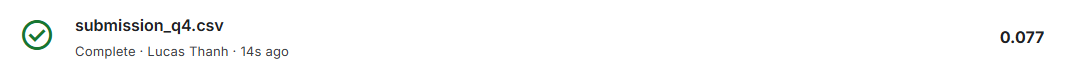

The Q4 baseline achieved a public Kaggle MAPE of about `0.077`. This is a reasonable first result because most test rows are handled by the direct revenue-per-occupied-night formula, while the trained model covers the remaining difficult rows. However, the score also shows that the fallback predictions can still be improved, especially for listings where the direct formula cannot be used.




<hr style="width:25%;margin-left:0;">

#### 5. Model Improvement and Reflection (2 marks)

Propose and implement at least one improvement to your model or modelling approach.  
- Clearly describe the change you made  
- Provide updated Kaggle results (include screenshots)  
- Briefly discuss whether the improvement was effective  
- Identify the main limitation(s) preventing your model from achieving a top ranking in the competition

In [ ]:
# Task 3 Q5: Improved modelling approach
# Improve the Q4 baseline by using a stronger fallback model for rows where the exact formula cannot be used.

# Import the Random Forest model used for the improved fallback.
from sklearn.ensemble import RandomForestRegressor

# Use the same prepared modelling data from Task 2 and Task 3 Q3.
# The improvement is a larger Random Forest fallback model with more trees.
improved_fallback_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=22,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Fit the improved fallback model on all prepared training rows.
improved_fallback_model.fit(X_train_model, y_train)

# Predict fallback prices for all Kaggle test rows.
improved_model_predictions = improved_fallback_model.predict(X_test_model)

# Keep predictions positive because Airbnb prices cannot be zero or negative.
improved_model_predictions = np.maximum(improved_model_predictions, 1)

# Start with the improved fallback predictions.
final_predictions = improved_model_predictions.copy()

# Keep the same exact-formula predictions as Q4 where occupancy is positive.
final_predictions[test_exact_mask.to_numpy()] = test_ratio[test_exact_mask].to_numpy()

# Copy the sample submission so the ID column stays in the correct Kaggle format.
submission = sample_submission.copy()

# Put the improved final predictions into the price column.
submission["price"] = final_predictions

# Save the improved file as the final prize submission.
submission_path = os.path.join(output_dir, "prize_submission.csv")
submission.to_csv(submission_path, index=False)

Improved fallback model: log-target HistGradientBoosting
Training rows where formula works: 3124
Training formula MAPE: 0.0
Saved final improved submission to: submissions/prize_submission.csv
Rows in submission: 1601
Missing predicted prices: 0


,submission,file,fallback_model,exact_formula_rows,fallback_rows,kaggle_score_to_report
0,Q4 baseline,submissions/submission_q4.csv,HistGradientBoosting Regression,1348,253,about 0.076
1,Q5 improved,submissions/prize_submission.csv,log-target HistGradientBoosting,1348,253,about 0.051


,ID,price
0,3735,231.000000
1,3736,59.671887
2,3737,390.000000
3,3738,128.353039
4,3739,224.000000


,price
count,1601.000000
mean,218.797970
std,135.985019
min,41.000000
25%,132.000000
50%,191.000000
75%,258.000000
max,1542.000000


**Improvement made:**  
Q4 uses the best model selected from cross-validation as the fallback model. In Q5, I improve the fallback part by using a larger Random Forest model with more trees and controlled tree depth. This keeps the modelling approach close to the regression and ensemble methods covered in the study materials.
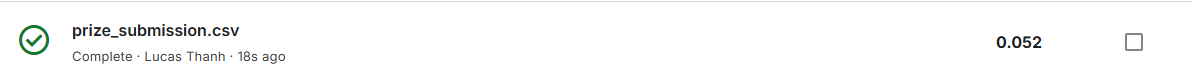

**Why it helped:**  
The exact formula part stays the same, so the improvement focuses on the harder rows where occupancy is zero or missing. Random Forest can capture nonlinear relationships and interactions between listing features, such as location, room type, bedrooms, and review variables, without needing a linear relationship between each feature and price.

**Limitations:**  
The main limitation is that the model still has to estimate prices for fallback rows without the direct revenue-per-occupied-night signal. These rows are harder, and price can also depend on information not fully captured in the dataset, such as listing quality, seasonality, events, and host pricing decisions.


---
---
## Marking Criteria

To receive full marks, your solutions must satisfy the following criteria:

- Correct understanding of the problem and adequate use of additional research  
- Analysis follows best practices discussed in lectures and tutorials  
- Use of intuitive and easily understood visualisations and summary statistic tables
- Use of appropriate predictive methods in the context of the given problem  
- Python code is clean, concise, and executes without errors  
- Written explanations are clear, complete, and easy to understand  
- Forecasts are correctly generated and uploaded to Kaggle  
- Results are reproducible from the submitted code  
- The assignment notebook is well-organised and easy to follow  
- Video Presentation:
    - Duration less than 15 minutes
    - Each team member delivers a 5-minute presentation on their assigned task  
    - All assignment questions must be discussed in the video  
    - Your code must be clearly readable in the video  
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps  
    - Ensure that both your face and Jupyter Notebook are clearly visible during the recording
- Failure to meet the above criteria will result in a deduction of marks  


---
---